# Statistical Customer Segmentation System

## Notebook 05: Customer Segmentation

### Purpose

This notebook applies clustering algorithms to identify distinct customer segments based on purchasing behavior.

### Objectives

- Determine the optimal number of customer clusters
- Apply K-Means clustering
- Perform hierarchical clustering
- Visualize customer segments
- Develop interpretable customer groups

### Expected Outcome

Meaningful customer segments that support data-driven marketing and customer relationship strategies.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import linkage

from sklearn.decomposition import PCA

import os

os.makedirs("images", exist_ok=True)

In [2]:
rfm = pd.read_csv(
    "/content/rfm_dataset.csv",
    index_col=0
)

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12347.0,37,1,711.79
12348.0,27,1,892.80
12359.0,1,1,547.50
12370.0,27,2,1864.27
12377.0,24,1,1001.52


## Standardization

Clustering algorithms are sensitive to scale. Therefore, all RFM variables are standardized.

In [3]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm
)

rfm_scaled[:5]

array([[ 0.90236329, -0.10759977, -0.02409835],
       [ 0.19195248, -0.10759977,  0.00436666],
       [-1.6551156 , -0.10759977, -0.04993403],
       [ 0.19195248, -0.02533513,  0.1571367 ],
       [-0.02117076, -0.10759977,  0.0214636 ]])

## Determining the Number of Clusters

The Elbow Method is used to identify an appropriate number of customer segments.

In [4]:
inertia = []

for k in range(1, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(
        rfm_scaled
    )

    inertia.append(
        kmeans.inertia_
    )

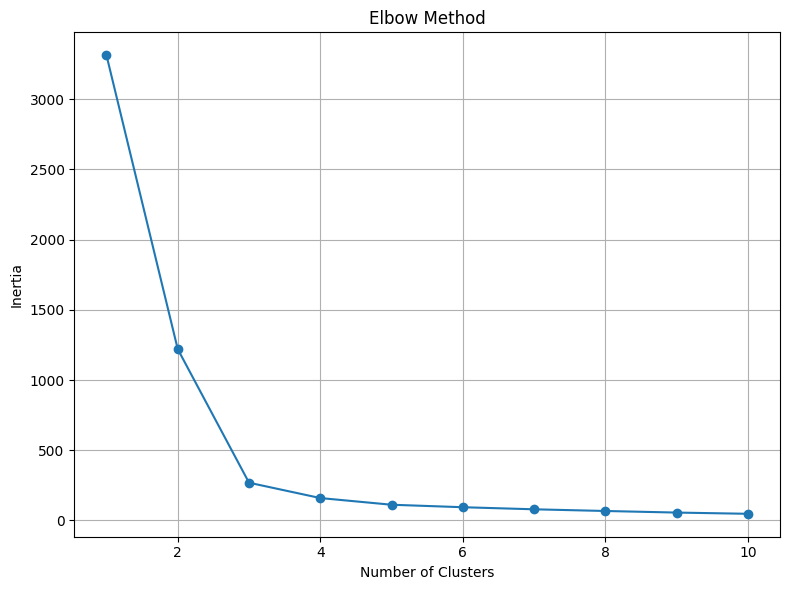

In [5]:
plt.figure(figsize=(8,6))

plt.plot(
    range(1,11),
    inertia,
    marker="o"
)

plt.title(
    "Elbow Method"
)

plt.xlabel(
    "Number of Clusters"
)

plt.ylabel(
    "Inertia"
)

plt.grid()

plt.tight_layout()

plt.savefig(
    "images/elbow_method.png",
    dpi=300
)

plt.show()

## K-Means Clustering

Based on the elbow method, we initially use 3 clusters.

In [6]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(
    rfm_scaled
)

rfm["Cluster"] = clusters

rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12347.0,37,1,711.79,0
12348.0,27,1,892.80,0
12359.0,1,1,547.50,2
12370.0,27,2,1864.27,0
12377.0,24,1,1001.52,0


In [7]:
rfm["Cluster"].value_counts()

,count
Cluster,
0,768
2,335
1,1


In [8]:
pca = PCA(
    n_components=2
)

rfm_pca = pca.fit_transform(
    rfm_scaled
)

pca_df = pd.DataFrame(
    rfm_pca,
    columns=["PC1","PC2"]
)

pca_df["Cluster"] = clusters

pca_df.head()

,PC1,PC2,Cluster
0,-0.221348,0.879510,0
1,-0.099708,0.179232,0
2,0.126739,-1.654150,2
3,0.064788,0.202844,0
4,-0.057225,-0.030008,0


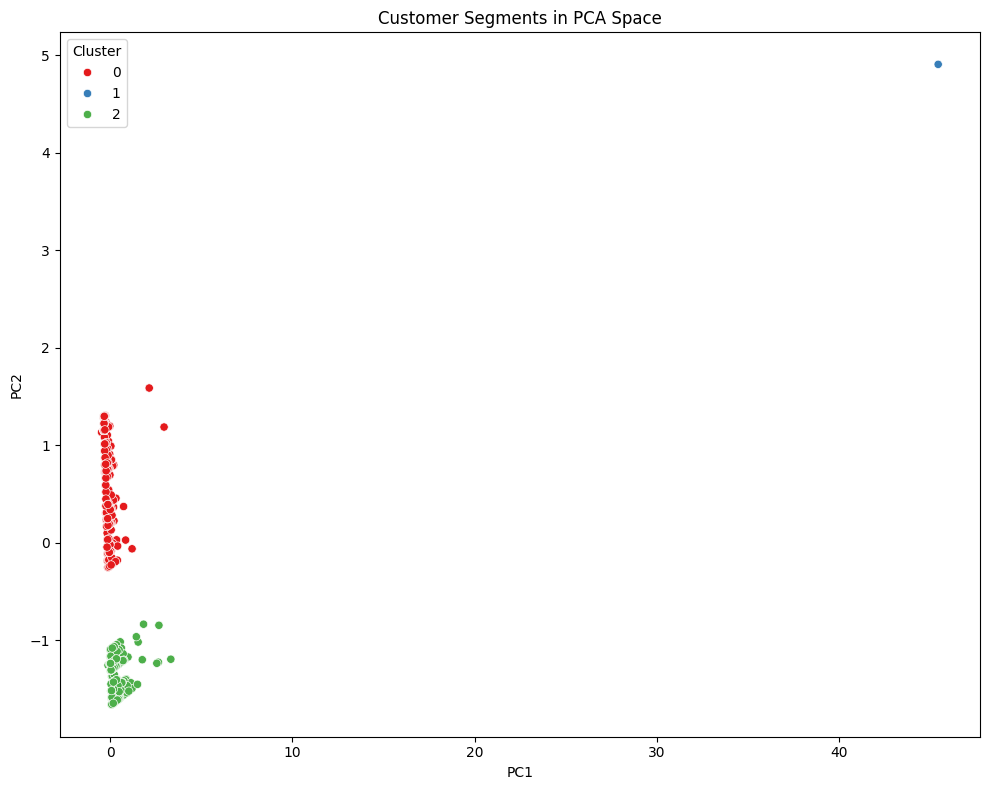

In [9]:
plt.figure(figsize=(10,8))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set1"
)

plt.title(
    "Customer Segments in PCA Space"
)

plt.tight_layout()

plt.savefig(
    "images/cluster_scatter_pca.png",
    dpi=300
)

plt.show()

## Cluster Distribution

In [10]:
cluster_counts = (
    rfm["Cluster"]
    .value_counts()
    .sort_index()
)

cluster_counts

,count
Cluster,
0,768
1,1
2,335


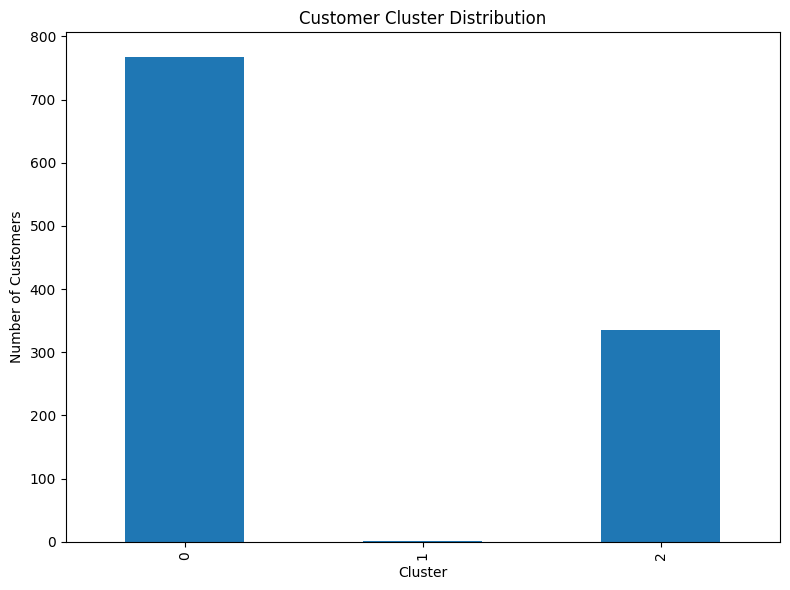

In [11]:
plt.figure(figsize=(8,6))

cluster_counts.plot(
    kind="bar"
)

plt.title(
    "Customer Cluster Distribution"
)

plt.ylabel(
    "Number of Customers"
)

plt.tight_layout()

plt.savefig(
    "images/cluster_distribution.png",
    dpi=300
)

plt.show()

## Cluster Profiles

In [12]:
cluster_profile = (
    rfm.groupby("Cluster")
       [["Recency",
         "Frequency",
         "Monetary"]]
       .mean()
       .round(2)
)

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,32.93,1.58,458.23
1,1.00,399.00,204223.96
2,4.59,2.79,1190.60


## Hierarchical Clustering

Hierarchical clustering provides a secondary segmentation perspective.

In [14]:
sample = rfm.sample(
    n=200,
    random_state=42
)

sample_scaled = scaler.fit_transform(
    sample[
        ["Recency",
         "Frequency",
         "Monetary"]
    ]
)

In [15]:
linked = linkage(
    sample_scaled,
    method="ward"
)

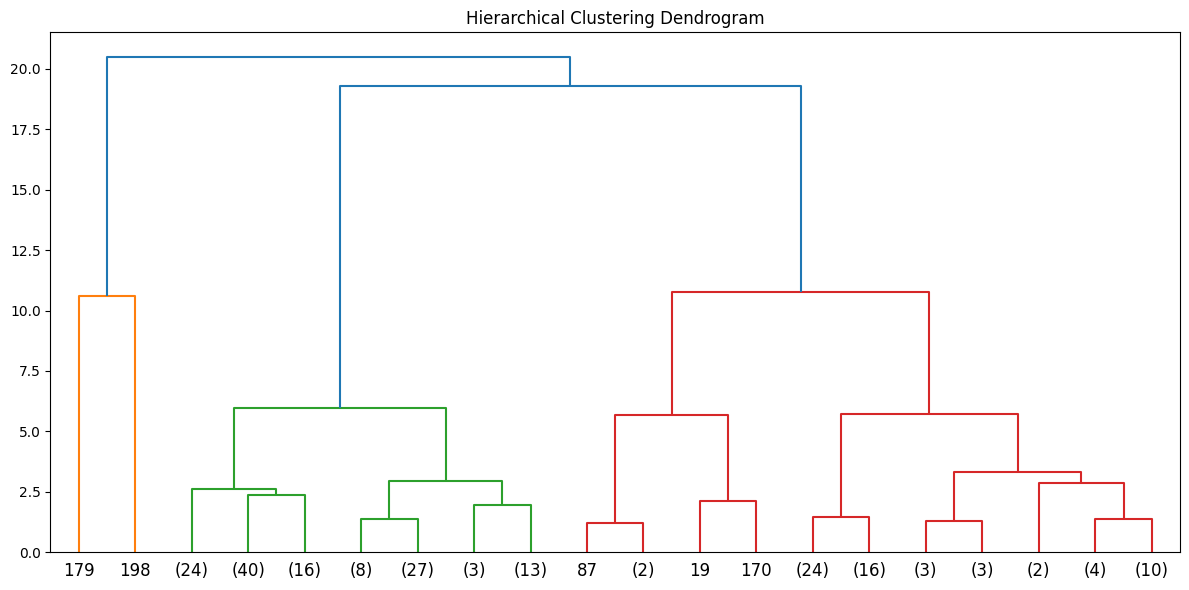

In [16]:
plt.figure(figsize=(12,6))

dendrogram(
    linked,
    truncate_mode="lastp",
    p=20
)

plt.title(
    "Hierarchical Clustering Dendrogram"
)

plt.tight_layout()

plt.savefig(
    "images/hierarchical_dendrogram.png",
    dpi=300
)

plt.show()

In [17]:
rfm.to_csv(
    "customer_segments.csv"
)

print(
    "Customer segmentation dataset saved successfully."
)

Customer segmentation dataset saved successfully.


## Findings

Customer segmentation successfully identified distinct groups based on purchasing behavior.

The resulting clusters differ in recency, purchasing frequency, and spending behavior, indicating meaningful customer heterogeneity.

These segments provide a foundation for targeted marketing strategies, customer retention efforts, and business decision-making.